In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
import seaborn as sns

# Plotly grafiklerinin HTML çıktısında düzgün gömülmesi için varsayılan ayar
pio.renderers.default = "notebook"

# Görsel stil ayarları
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [10]:
import os
import pandas as pd
import numpy as np

# 1. 'data' klasörünü otomatik olarak oluşturuyoruz
os.makedirs("data", exist_ok=True)

# 2. Ödev kriterlerine uygun (350 satır, 6 sütun) örnek bir veri seti üretiyoruz
np.random.seed(42)
satir_sayisi = 350
kategoriler = ["Elektronik", "Giyim", "Ev & Yaşam", "Kozmetik", "Kitap"]

veri = {
    "musteri_id": range(1001, 1001 + satir_sayisi),
    "yas": np.random.randint(18, 65, size=satir_sayisi),
    "kategori": np.random.choice(kategoriler, size=satir_sayisi, p=[0.3, 0.25, 0.2, 0.15, 0.1]),
    # DÜZELTME: np.random.round yerine doğrudan np.round yazarak hatayı çözdük
    "fiyat": np.round(np.random.uniform(100, 4000, size=satir_sayisi), 2),
    "miktar": np.random.randint(1, 6, size=satir_sayisi)
}

df_taslak = pd.DataFrame(veri)
# Toplam harcama sütununu ekleyelim
df_taslak["harcama"] = df_taslak["fiyat"] * df_taslak["miktar"]

# Ödevdeki 'eksik değer incelemesi' kriteri için rastgele 5 satırın yaş bilgisini boş (NaN) bırakalım[cite: 1]
df_taslak.loc[df_taslak.sample(n=5).index, "yas"] = np.nan

# Veriyi csv olarak kaydedelim[cite: 1]
df_taslak.to_csv("data/veri_seti.csv", index=False, encoding="utf-8")
print("✅ 'data' klasörü ve 350 satırlık 'veri_seti.csv' başarıyla oluşturuldu!")

✅ 'data' klasörü ve 350 satırlık 'veri_seti.csv' başarıyla oluşturuldu!


In [11]:
# Veri setinin bilgisayarındaki yerini belirtiyoruz (Göreceli dosya yolu)
dosya_yolu = "data/veri_seti.csv" 

try:
    # Türkçe karakter sorununu önlemek için encoding='utf-8' ayarıyla yüklüyoruz
    df = pd.read_csv(dosya_yolu, encoding="utf-8") 
    print("✅ Veri seti başarıyla yüklendi!")
    
    # Ödev kriteri: Verinin boyutunu (satır/sütun sayısı) ekrana yazdırıyoruz
    print(f"Boyut Bilgisi: {df.shape[0]} satır, {df.shape[1]} sütun\n")
    
    # Verinin ilk 5 satırını tablo olarak inceliyoruz
    print("--- Verinin İlk 5 Satırı ---")
    display(df.head())
    
    # Eksik (boş) değerleri kontrol ediyoruz
    print("\n--- Eksik Değer Kontrolü ---")
    print(df.isnull().sum())
    
except FileNotFoundError:
    print(f"❌ Hata: '{dosya_yolu}' konumunda dosya bulunamadı!")
    print("Lütfen projenizin içinde 'data' adında bir klasör olduğundan ve içinde veri setinizin olduğundan emin olun.")

✅ Veri seti başarıyla yüklendi!
Boyut Bilgisi: 350 satır, 6 sütun

--- Verinin İlk 5 Satırı ---


,musteri_id,yas,kategori,fiyat,miktar,harcama
0,1001,56.0,Kozmetik,790.34,2,1580.68
1,1002,46.0,Giyim,445.94,5,2229.70
2,1003,32.0,Elektronik,570.48,1,570.48
3,1004,60.0,Ev & Yaşam,1897.04,2,3794.08
4,1005,25.0,Kitap,904.70,5,4523.50



--- Eksik Değer Kontrolü ---
musteri_id    0
yas           5
kategori      0
fiyat         0
miktar        0
harcama       0
dtype: int64


In [12]:
# 1. Genel Tanımsal İstatistik Özeti (Merkezi eğilim ve yayılım ölçüleri)
print("📊 Sayısal Değişkenlerin Tanımsal İstatistik Özeti:")
display(df.describe())

# 2. Kategorik Değişkenlerin Dağılımı (Frekans ve Yüzde hesabı)
print("\n🛍️ Kategori Bazlı Dağılım (Müşteri Frekansı ve Yüzdesi):")
frekans = df["kategori"].value_counts()
yuzde = df["kategori"].value_counts(normalize=True) * 100
display(pd.DataFrame({"Frekans": frekans, "Yüzde (%)": yuzde}))

# 3. Gruplandırılmış İstatistikler (Ürün kategorilerine göre harcama alışkanlıkları)
print("\n💰 Ürün Kategorilerine Göre Harcama Ortalama ve Standart Sapmaları:")
grup_ozet = df.groupby("kategori").agg({"harcama": ["mean", "std"], "miktar": ["sum", "count"]})
display(grup_ozet)

# 4. Değişkenler Arası Korelasyon Matrisi (Harcama, yaş, fiyat ilişkisi)
print("\n🔗 Sayısal Değişkenler Arası Doğrusal İlişki (Korelasyon):")
korelasyon = df.select_dtypes(include=np.number).corr()
display(korelasyon)

📊 Sayısal Değişkenlerin Tanımsal İstatistik Özeti:


,musteri_id,yas,fiyat,miktar,harcama
count,350.000000,345.000000,350.000000,350.000000,350.000000
mean,1175.500000,41.214493,1950.525686,2.991429,5819.392257
std,101.180532,13.474796,1107.100665,1.419244,4626.684959
min,1001.000000,18.000000,118.060000,1.000000,203.480000
25%,1088.250000,30.000000,934.910000,2.000000,2184.112500
50%,1175.500000,42.000000,1899.430000,3.000000,4482.330000
75%,1262.750000,52.000000,2904.177500,4.000000,8054.595000
max,1350.000000,64.000000,3987.810000,5.000000,19704.400000



🛍️ Kategori Bazlı Dağılım (Müşteri Frekansı ve Yüzdesi):


,Frekans,Yüzde (%)
kategori,,
Elektronik,100,28.571429
Giyim,83,23.714286
Ev & Yaşam,69,19.714286
Kozmetik,56,16.000000
Kitap,42,12.000000



💰 Ürün Kategorilerine Göre Harcama Ortalama ve Standart Sapmaları:


harcama              miktar      
                   mean          std    sum count
kategori                                         
Elektronik  5680.287900  4425.262341    288   100
Ev & Yaşam  5638.278986  4819.855769    203    69
Giyim       6251.065301  4764.577505    272    83
Kitap       6200.237857  4372.904454    126    42
Kozmetik    5365.515000  4804.435632    158    56


🔗 Sayısal Değişkenler Arası Doğrusal İlişki (Korelasyon):


,musteri_id,yas,fiyat,miktar,harcama
musteri_id,1.000000,0.039835,0.025460,0.065837,0.045866
yas,0.039835,1.000000,-0.019859,-0.000914,0.019872
fiyat,0.025460,-0.019859,1.000000,-0.009871,0.709504
miktar,0.065837,-0.000914,-0.009871,1.000000,0.605272
harcama,0.045866,0.019872,0.709504,0.605272,1.000000


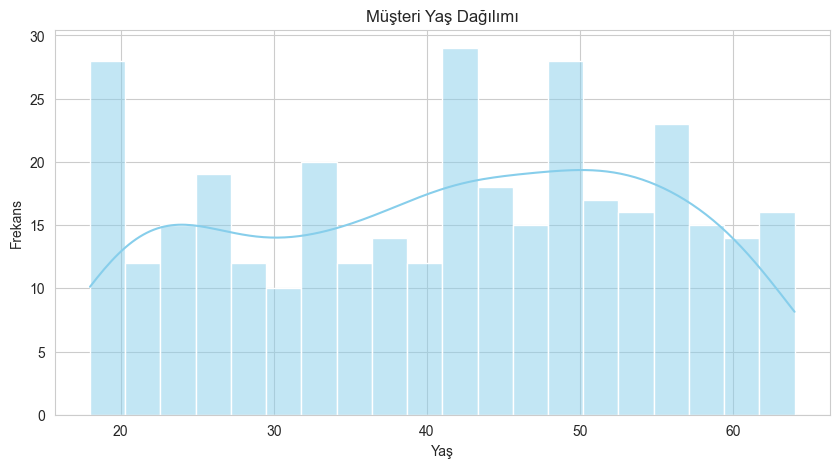

In [13]:
# 1. Grafik: Histogram (Yaş Dağılımı)
sns.histplot(df["yas"], bins=20, kde=True, color="skyblue")
plt.title("Müşteri Yaş Dağılımı")
plt.xlabel("Yaş")
plt.ylabel("Frekans")
plt.show()